In [160]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer

In [161]:
df = pd.read_csv("D:\Code_data\DESU_2026\global_climate_co2_anomalies.csv")

<>:1: SyntaxWarning:

invalid escape sequence '\C'

<>:1: SyntaxWarning:

invalid escape sequence '\C'

C:\Users\julie\AppData\Local\Temp\ipykernel_22124\2610510494.py:1: SyntaxWarning:

invalid escape sequence '\C'



In [162]:
# Garder une seule ligne par pays/année au lieu de 12
df_annual = df.drop_duplicates(subset=['country','year'], keep='first')

In [163]:
df_annual.head()

,country,iso_code,year,month,continent,income_group,latitude,longitude,latitude_band,climate_zone,temp_anomaly_global,temp_anomaly_land,temp_anomaly_ocean,temp_anomaly_arctic,temp_max,temp_min,co2_emissions,co2_per_capita,co2_per_gdp,cumulative_co2,co2_concentration_ppm,methane_emissions,nitrous_oxide,total_ghg,land_use_change_co2,sea_ice_extent_arctic,sea_ice_extent_antarc,sea_surface_temp_anom,nino34_index,ocean_heat_content,precipitation_anomaly,drought_index_pdsi,spi_3month,primary_energy_twh,share_renewables_pct,share_coal_pct,co2_per_kwh,electricity_demand_twh,renewable_capacity_gw,oil_production,population_millions,gdp_per_capita_usd,population_density,urbanization_rate,forest_cover_pct,industrial_share_gdp,agriculture_share_gdp,vehicle_ownership,radiative_forcing,temp_change_from_co2,climate_risk_score,warming_category,renewable_transition_stage,emission_intensity_level
0,Argentina,ARG,1990,1,South America,Upper Middle,-34.0,-64.0,Temperate,Temperate,0.40,0.88,0.28,0.82,-7.0,-19.6,150.6,4.21,0.1506,151.0,354,27.1,10.6,199.7,-0.2,13.93,10.49,0.15,-0.01,-5.19,1.4,0.51,-0.13,184.8,9.4,2.3,325.9,64.7,12.2,0.51,37.00,8749.0,13309.4,89.0,11,23,8,264.0,2.000,0.29,12.2,Normal,Low,Medium
12,Argentina,ARG,1991,1,South America,Upper Middle,-34.0,-64.0,Temperate,Temperate,0.47,0.89,0.33,1.03,-6.3,-18.7,161.8,4.41,0.1618,312.0,356,28.7,9.0,218.3,2.5,13.66,11.63,0.27,0.92,-3.44,94.0,2.12,1.25,214.9,8.0,2.5,301.1,75.2,12.0,0.56,37.37,9421.0,13442.4,89.9,11,23,8,276.0,2.059,0.27,17.7,Normal,Low,Medium
24,Argentina,ARG,1992,1,South America,Upper Middle,-34.0,-64.0,Temperate,Temperate,0.23,0.64,0.08,0.50,-6.3,-20.0,152.1,3.96,0.1521,464.0,356,20.9,8.5,207.4,-1.2,13.78,12.00,0.01,0.30,-2.28,-36.2,-0.31,-0.55,191.9,9.7,1.7,317.0,67.2,13.0,0.53,37.74,9540.0,13575.5,91.9,11,23,8,278.0,2.118,0.17,10.5,Normal,Low,Medium
36,Argentina,ARG,1993,1,South America,Upper Middle,-34.0,-64.0,Temperate,Temperate,0.21,0.60,0.02,0.30,-5.2,-15.3,153.6,4.57,0.1536,618.0,357,32.2,9.0,214.8,1.4,13.71,10.88,0.01,0.19,-1.07,45.0,0.84,0.82,205.3,8.6,1.7,299.3,71.9,12.4,0.52,38.12,10023.0,13712.2,90.4,11,23,8,284.0,2.177,0.17,9.3,Normal,Low,Medium
48,Argentina,ARG,1994,1,South America,Upper Middle,-34.0,-64.0,Temperate,Temperate,0.40,0.78,0.25,0.76,-8.2,-20.8,166.3,4.41,0.1663,784.0,359,29.3,11.2,227.4,-1.1,13.56,11.38,0.18,1.26,0.50,-43.4,-0.40,-0.40,218.1,9.6,2.6,305.0,76.3,14.7,0.51,38.50,10295.0,13848.9,92.2,11,23,8,275.0,2.236,0.22,15.6,Normal,Low,Medium


In [164]:
for col in df.columns:
    print(col)

country
iso_code
year
month
continent
income_group
latitude
longitude
latitude_band
climate_zone
temp_anomaly_global
temp_anomaly_land
temp_anomaly_ocean
temp_anomaly_arctic
temp_max
temp_min
co2_emissions
co2_per_capita
co2_per_gdp
cumulative_co2
co2_concentration_ppm
methane_emissions
nitrous_oxide
total_ghg
land_use_change_co2
sea_ice_extent_arctic
sea_ice_extent_antarc
sea_surface_temp_anom
nino34_index
ocean_heat_content
precipitation_anomaly
drought_index_pdsi
spi_3month
primary_energy_twh
share_renewables_pct
share_coal_pct
co2_per_kwh
electricity_demand_twh
renewable_capacity_gw
oil_production
population_millions
gdp_per_capita_usd
population_density
urbanization_rate
forest_cover_pct
industrial_share_gdp
agriculture_share_gdp
vehicle_ownership
radiative_forcing
temp_change_from_co2
climate_risk_score
warming_category
renewable_transition_stage
emission_intensity_level


Text(0.5, 0, 'population_millions (moyenne 1990-2024)')

Text(0, 0.5, 'co2_emissions (moyenne 1990-2024)')

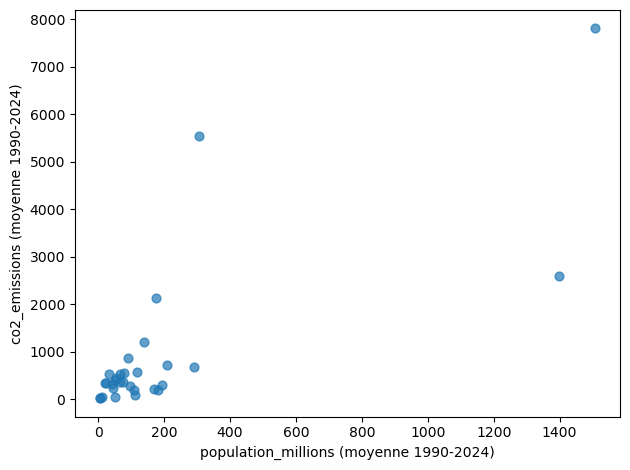

In [165]:
# Un point = un pays : moyenne sur les 35 ans
df_by_country = df_annual.groupby('country')[['population_millions','co2_emissions']].mean().reset_index()

plt.scatter(df_by_country['population_millions'], df_by_country['co2_emissions'], alpha=0.7, s=40)

plt.xlabel('population_millions (moyenne 1990-2024)')
plt.ylabel('co2_emissions (moyenne 1990-2024)')
plt.tight_layout()
plt.show()

Text(4, 4, 'Argentina')

Text(4, 4, 'Australia')

Text(4, 4, 'Bangladesh')

Text(4, 4, 'Brazil')

Text(4, 4, 'Canada')

...

Text(4, 4, 'United Kingdom')

Text(4, 4, 'United States')

Text(4, 4, 'Vietnam')

Text(0.5, 0, 'co2_emissions (moyenne 1990-2024)')

Text(0, 0.5, 'population_millions (moyenne 1990-2024)')

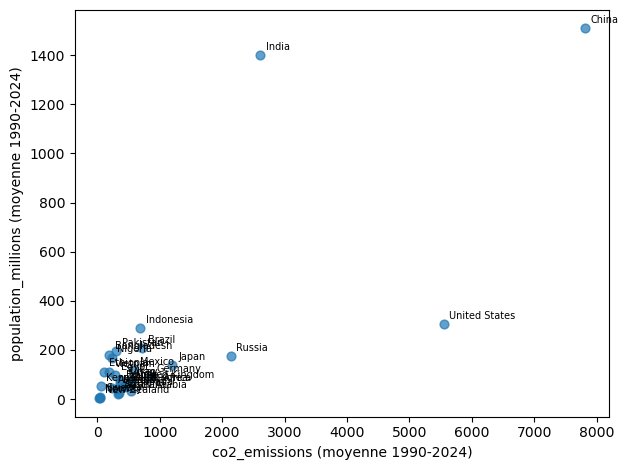

In [166]:
plt.scatter(df_by_country['co2_emissions'], df_by_country['population_millions'], alpha=0.7, s=40)

for _, row in df_by_country.iterrows():
    plt.annotate(row['country'], (row['co2_emissions'], row['population_millions']),
                 fontsize=(7), xytext=(4,4), textcoords='offset points')

plt.xlabel('co2_emissions (moyenne 1990-2024)')
plt.ylabel('population_millions (moyenne 1990-2024)')
plt.tight_layout()
plt.show()

Text(4, 4, 'Argentina')

Text(4, 4, 'Australia')

Text(4, 4, 'Bangladesh')

Text(4, 4, 'Brazil')

Text(4, 4, 'Canada')

...

Text(4, 4, 'United Kingdom')

Text(4, 4, 'United States')

Text(4, 4, 'Vietnam')

Text(0.5, 0, 'population_millions (moyenne 1990-2024)')

Text(0, 0.5, 'co2_per_capita (moyenne 1990-2024)')

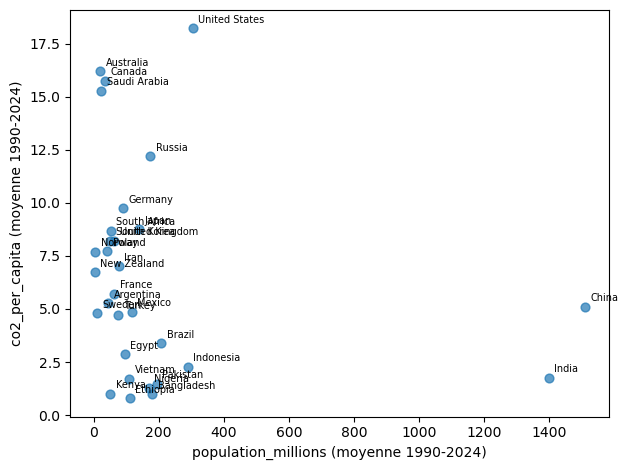

In [167]:
# Un point = un pays : moyenne sur les 35 ans
df_by_country = df_annual.groupby('country')[['population_millions','co2_per_capita']].mean().reset_index()

plt.scatter(df_by_country['population_millions'], df_by_country['co2_per_capita'], alpha=0.7, s=40)

for _, row in df_by_country.iterrows():
    plt.annotate(row['country'], (row['population_millions'], row['co2_per_capita']),
                 fontsize=(7), xytext=(4,4), textcoords='offset points')

plt.xlabel('population_millions (moyenne 1990-2024)')
plt.ylabel('co2_per_capita (moyenne 1990-2024)')
plt.tight_layout()
plt.show()

Text(4, 4, 'Argentina')

Text(4, 4, 'Australia')

Text(4, 4, 'Bangladesh')

Text(4, 4, 'Brazil')

Text(4, 4, 'Canada')

...

Text(4, 4, 'United States')

Text(4, 4, 'Vietnam')

Text(0.5, 0, 'population_millions')

Text(0, 0.5, 'co2_emissions / population_millions (recalculé)')

Text(0.5, 1.0, 'co2_per_capita — recalculé (2024)')

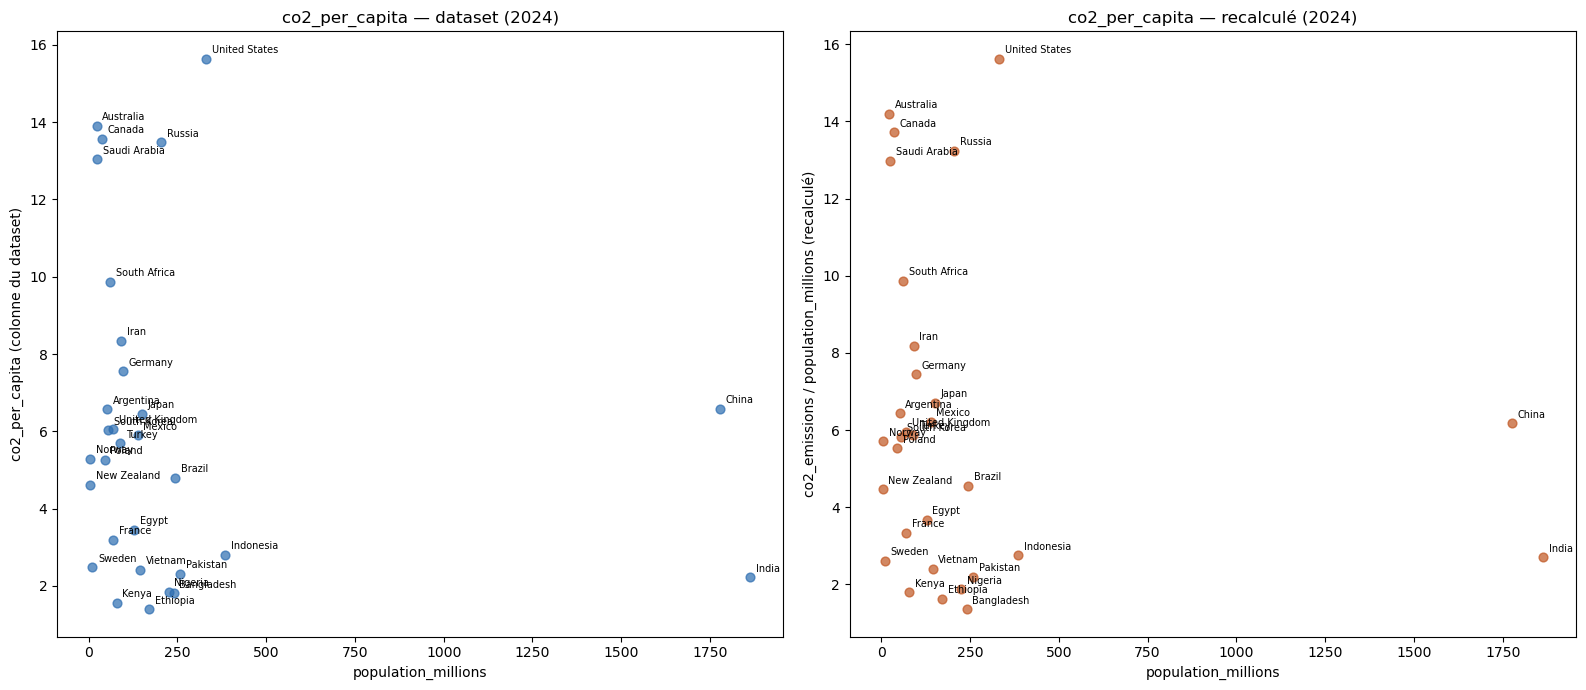

Écart absolu moyen: 0.19218796544860492
Écart absolu max: 0.47999195041455334
Corrélation: 0.9984291896658513


In [168]:
# Dernière année uniquement (2024), 1 point = 1 pays
df_last = df_annual[df_annual['year'] == df_annual['year'].max()].copy()
df_last['co2_pa_calc'] = df_last['co2_emissions'] / df_last['population_millions']

fig, axes = plt.subplots(1, 2, figsize=(16,7))

axes[0].scatter(df_last['population_millions'], df_last['co2_per_capita'], alpha=0.7, s=40, color='#2b6cb0')
for _, row in df_last.iterrows():
    axes[0].annotate(row['country'], (row['population_millions'], row['co2_per_capita']), fontsize=7, xytext=(4,4), textcoords='offset points')
axes[0].set_xlabel('population_millions')
axes[0].set_ylabel('co2_per_capita (colonne du dataset)')
axes[0].set_title(f"co2_per_capita — dataset ({int(df_annual['year'].max())})")

axes[1].scatter(df_last['population_millions'], df_last['co2_pa_calc'], alpha=0.7, s=40, color='#c05621')
for _, row in df_last.iterrows():
    axes[1].annotate(row['country'], (row['population_millions'], row['co2_pa_calc']), fontsize=7, xytext=(4,4), textcoords='offset points')
axes[1].set_xlabel('population_millions')
axes[1].set_ylabel('co2_emissions / population_millions (recalculé)')
axes[1].set_title(f"co2_per_capita — recalculé ({int(df_annual['year'].max())})")

plt.tight_layout()
plt.show()

diff = (df_last['co2_per_capita'] - df_last['co2_pa_calc']).abs()
print("Écart absolu moyen:", diff.mean())
print("Écart absolu max:", diff.max())
print("Corrélation:", df_last['co2_per_capita'].corr(df_last['co2_pa_calc']))



Text(0.5, 0, 'co2_emissions (moyenne 1990-2024)')

Text(0, 0.5, 'co2_per_capita (moyenne 1990-2024)')

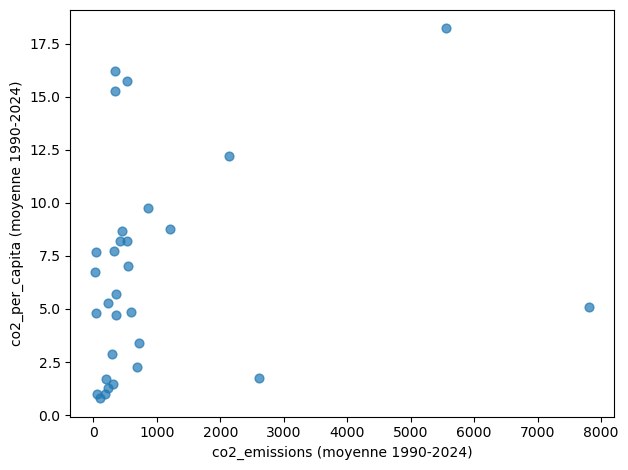

In [169]:
# Un point = un pays : moyenne sur les 35 ans
df_by_country = df_annual.groupby('country')[['co2_emissions','co2_per_capita']].mean().reset_index()

plt.scatter(df_by_country['co2_emissions'], df_by_country['co2_per_capita'], alpha=0.7, s=40)

plt.xlabel('co2_emissions (moyenne 1990-2024)')
plt.ylabel('co2_per_capita (moyenne 1990-2024)')
plt.tight_layout()
plt.show()

In [170]:
print(df_annual['country'].unique())

['Argentina' 'Australia' 'Bangladesh' 'Brazil' 'Canada' 'China' 'Egypt'
 'Ethiopia' 'France' 'Germany' 'India' 'Indonesia' 'Iran' 'Japan' 'Kenya'
 'Mexico' 'New Zealand' 'Nigeria' 'Norway' 'Pakistan' 'Poland' 'Russia'
 'Saudi Arabia' 'South Africa' 'South Korea' 'Sweden' 'Turkey'
 'United Kingdom' 'United States' 'Vietnam']


différentes questions me viennent à l'esprit : 
on voit que le pays qui a le plus de CO2 emission n'est pas le pays qui  le plus de CO2 par habitnt. Ex : l'inde est le 3ème pays qui pollue le plus et le 2eme pys le + grands MAIS le CO2 pr hbitnt est faible. DONC ça voudrait dire que CO2 per capita n'est pas simplement calculé comme CO2goblal/nb d'habitant, mais est bien une donnée sur les habitudes de consommation des habitant donc emprunte carbonne individuelle.
On le voit au plot CO2 emission - CO2 par capita qui n'est pas corrélé. 
Pour vérifier, je vais ploter voiture VS CO2 per capita pour avoir une idée de si c'est corélé ou pas et comparer avec CO2 gobal;

Text(0.5, 0, 'vehicle_ownership')

Text(0, 0.5, 'co2_per_capita')

Text(0.5, 1.0, 'r = 0.82')

Text(0.5, 0, 'urbanization_rate')

Text(0, 0.5, 'co2_per_capita')

...

Text(0.5, 1.0, 'r = 0.54')

Text(0.5, 0, 'share_coal_pct')

Text(0, 0.5, 'co2_per_capita')

Text(0.5, 1.0, 'r = 0.11')

Text(0.5, 0.98, 'co2_per_capita vs variables socio-économiques (données annuelles, 1050 lignes)')

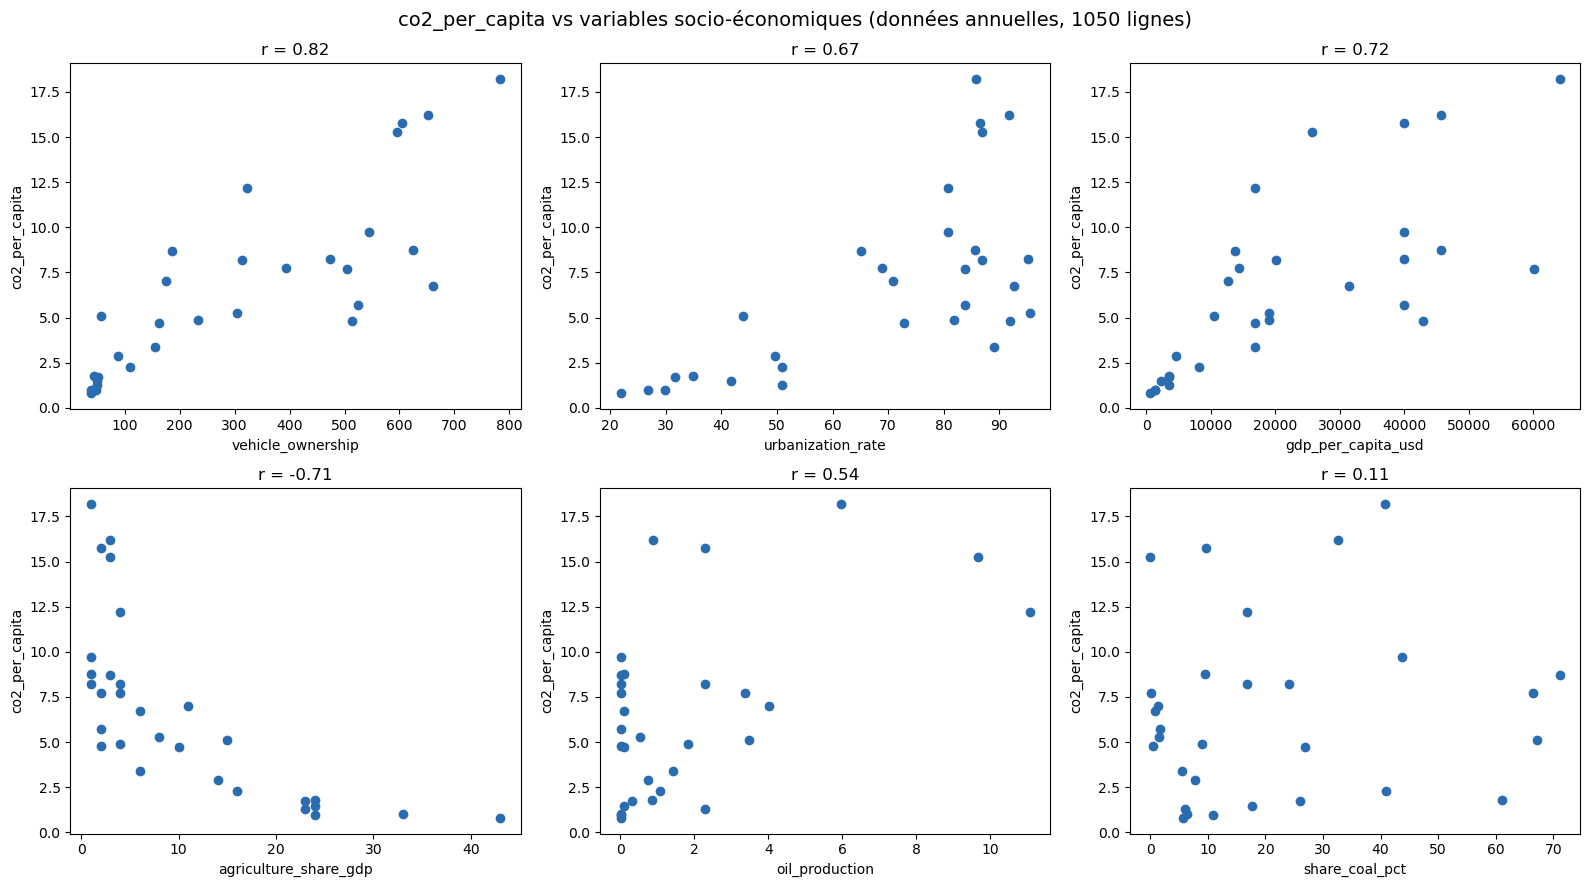

In [171]:
vars_to_plot = ['vehicle_ownership','urbanization_rate','gdp_per_capita_usd','agriculture_share_gdp',
                'oil_production','share_coal_pct']

df_by_country = df_annual.groupby('country')[vars_to_plot + ['co2_per_capita','co2_emissions']].mean().reset_index()


fig, axes = plt.subplots(2, 3, figsize=(16,9))
axes = axes.flatten()

for ax, var in zip(axes, vars_to_plot):
    ax.scatter(df_by_country[var], df_by_country['co2_per_capita'], color='#2b6cb0')
    ax.set_xlabel(var)
    ax.set_ylabel('co2_per_capita')
    corr = df_by_country[var].corr(df_by_country['co2_per_capita'])
    ax.set_title(f"r = {corr:.2f}")

plt.suptitle("co2_per_capita vs variables socio-économiques (données annuelles, 1050 lignes)", fontsize=14)
plt.tight_layout()

Text(0.5, 0, 'vehicle_ownership')

Text(0, 0.5, 'co2_emissions')

Text(0.5, 1.0, 'r = 0.03')

Text(0.5, 0, 'urbanization_rate')

Text(0, 0.5, 'co2_emissions')

...

Text(0.5, 1.0, 'r = 0.36')

Text(0.5, 0, 'share_coal_pct')

Text(0, 0.5, 'co2_emissions')

Text(0.5, 1.0, 'r = 0.52')

Text(0.5, 0.98, 'co2_emissions vs variables socio-économiques (données annuelles, 1050 lignes)')

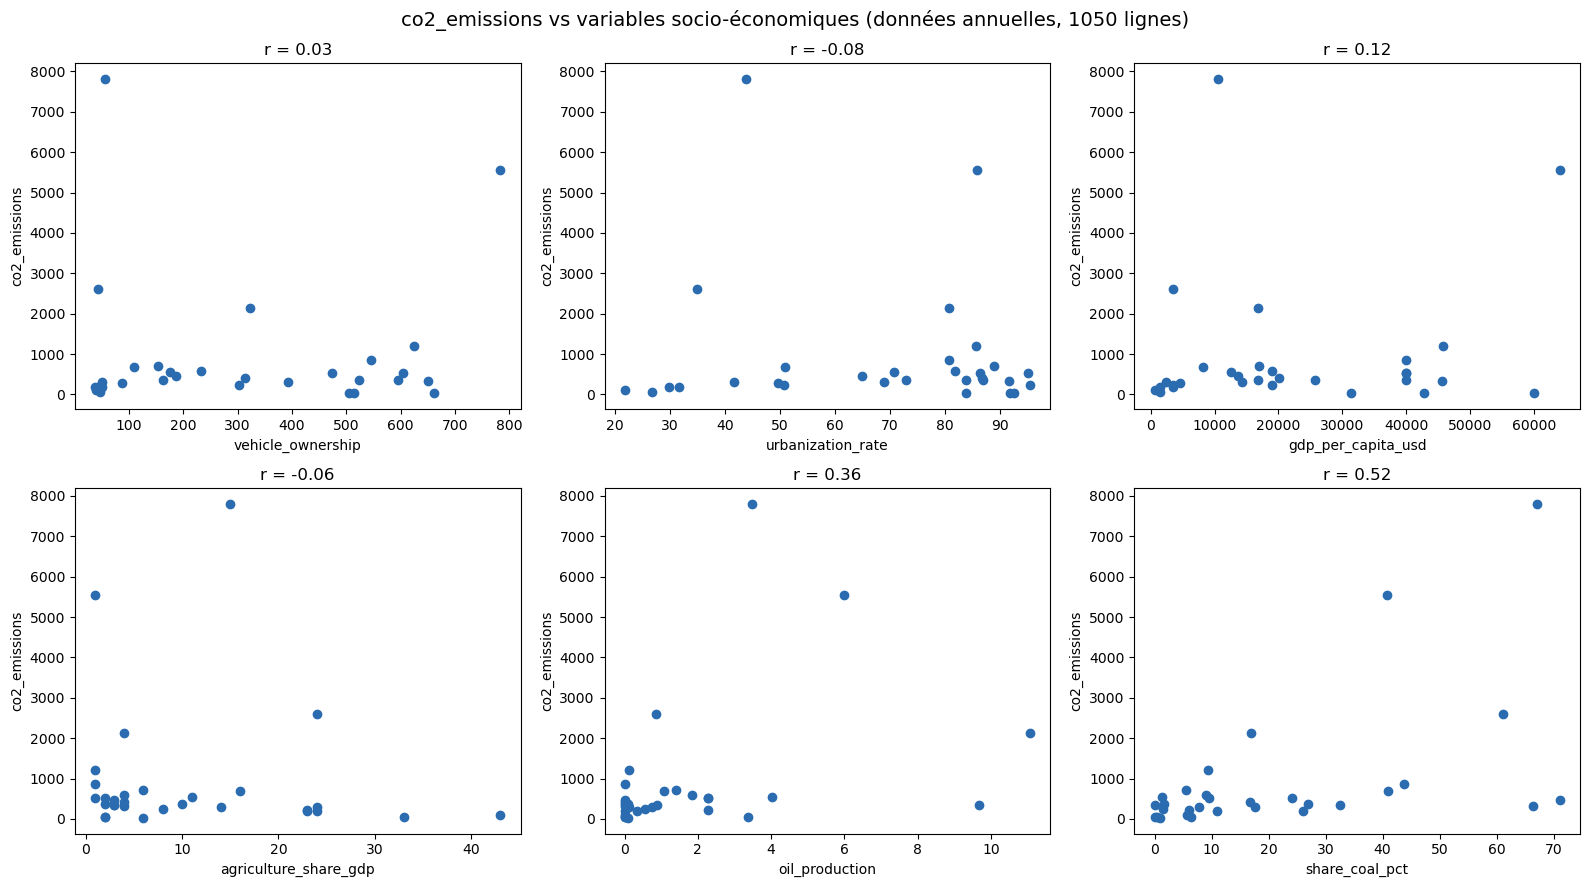

In [172]:
fig, axes = plt.subplots(2, 3, figsize=(16,9))
axes = axes.flatten()

for ax, var in zip(axes, vars_to_plot):
    ax.scatter(df_by_country[var], df_by_country['co2_emissions'], color='#2b6cb0')
    ax.set_xlabel(var)
    ax.set_ylabel('co2_emissions')
    corr = df_by_country[var].corr(df_by_country['co2_emissions'])
    ax.set_title(f"r = {corr:.2f}")

plt.suptitle("co2_emissions vs variables socio-économiques (données annuelles, 1050 lignes)", fontsize=14)
plt.tight_layout()

In [173]:
##toutes ces variables ne semblent pas expliquer les emissions de CO2 sauf peut etre share_coal_pct . Par contre certaines d'entre elles expliquent l'emprunte carbonne individuelle comme les voitures.

en fait la question, à laquelle on a déjà une idée de la réponse, est : est-ce que l'emprunte carbonne individuelle à elle seule explique les emissions de CO2 ? Si non, quelles sont les variables qui expliquent le plus ? 

Text(0.5, 0, 'nino34_index')

Text(0, 0.5, 'co2_emissions')

Text(0.5, 1.0, 'r = -0.01')

Text(0.5, 0, 'ocean_heat_content')

Text(0, 0.5, 'co2_emissions')

...

Text(0.5, 1.0, 'r = 0.05')

Text(0.5, 0, 'industrial_share_gdp')

Text(0, 0.5, 'co2_emissions')

Text(0.5, 1.0, 'r = 0.23')

Text(0.5, 0.98, 'co2_emissions vs variables socio-économiques (données annuelles, 1050 lignes)')

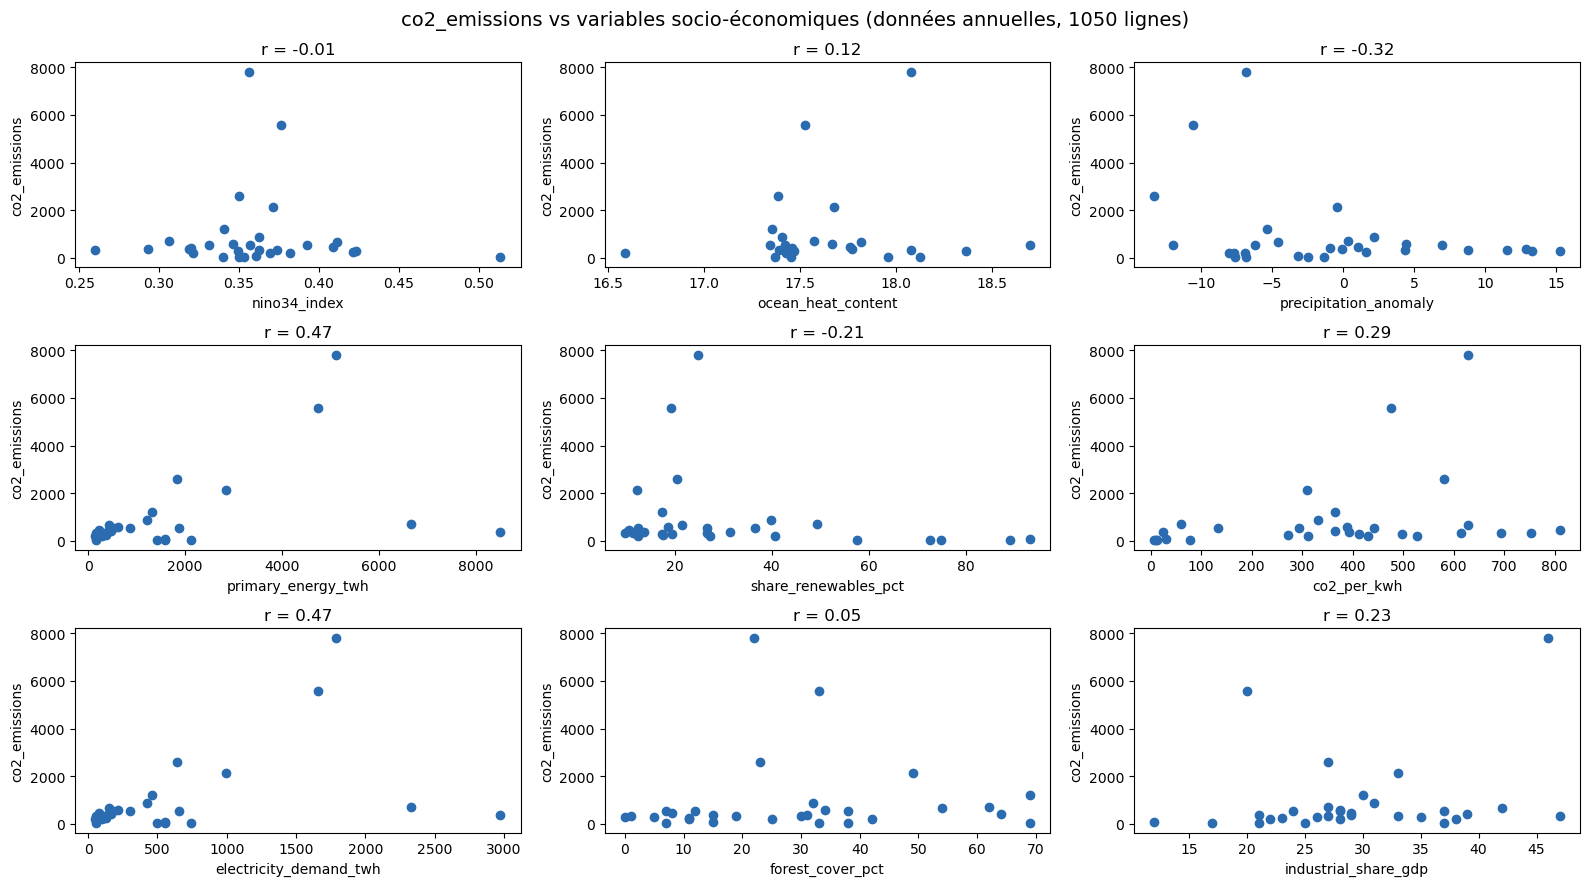

In [174]:
vars_to_plot = ['nino34_index','ocean_heat_content','precipitation_anomaly','primary_energy_twh','share_renewables_pct','co2_per_kwh','electricity_demand_twh','forest_cover_pct','industrial_share_gdp']

df_by_country = df_annual.groupby('country')[vars_to_plot + ['co2_emissions']].mean().reset_index()

fig, axes = plt.subplots(3, 3, figsize=(16,9))
axes = axes.flatten()

for ax, var in zip(axes, vars_to_plot):
    ax.scatter(df_by_country[var], df_by_country['co2_emissions'], color='#2b6cb0')
    ax.set_xlabel(var)
    ax.set_ylabel('co2_emissions')
    corr = df_by_country[var].corr(df_by_country['co2_emissions'])
    ax.set_title(f"r = {corr:.2f}")

plt.suptitle("co2_emissions vs variables socio-économiques (données annuelles, 1050 lignes)", fontsize=14)
plt.tight_layout()

##BON BAH MA QUESTION EST, vu que sur les plots aucune ou peu de relations linéaires se dessines, c'est cool : quelles variables expliquent le plus l'emission de CO2 d'un pays ? 
Evidemment j'imagine que la demande en electricité + la production de charbon + le nombre d'habitants sont les facteurs principaux. 

In [175]:
##finalement je change car j'ai comparé co2_per_capita du dataset avec co2_emissions / population_millions et les deux sont très proches. 
#Donc je peux utiliser co2_per_capita pour mes analyses, mais il ne faut pas garder CO2_emissions qui est directement dérivé 

In [176]:
print(df_annual['income_group'].unique())
print(df_annual['continent'].unique())

['Upper Middle' 'High Income' 'Lower Middle' 'Low Income']
['South America' 'Oceania' 'Asia' 'North America' 'Africa' 'Europe']


Text(0.5, 0, 'vehicle_ownership')

Text(0, 0.5, 'co2_per_capita')

Text(0.5, 0, 'urbanization_rate')

Text(0, 0.5, 'co2_per_capita')

Text(0.5, 0, 'gdp_per_capita_usd')

...

Text(0.5, 0, 'forest_cover_pct')

Text(0, 0.5, 'co2_per_capita')

Text(0.5, 0, 'share_renewables_pct')

Text(0, 0.5, 'co2_per_capita')

Text(0.5, 0.98, 'co2_per_capita vs variables socio-économiques — coloré par groupe de revenu')

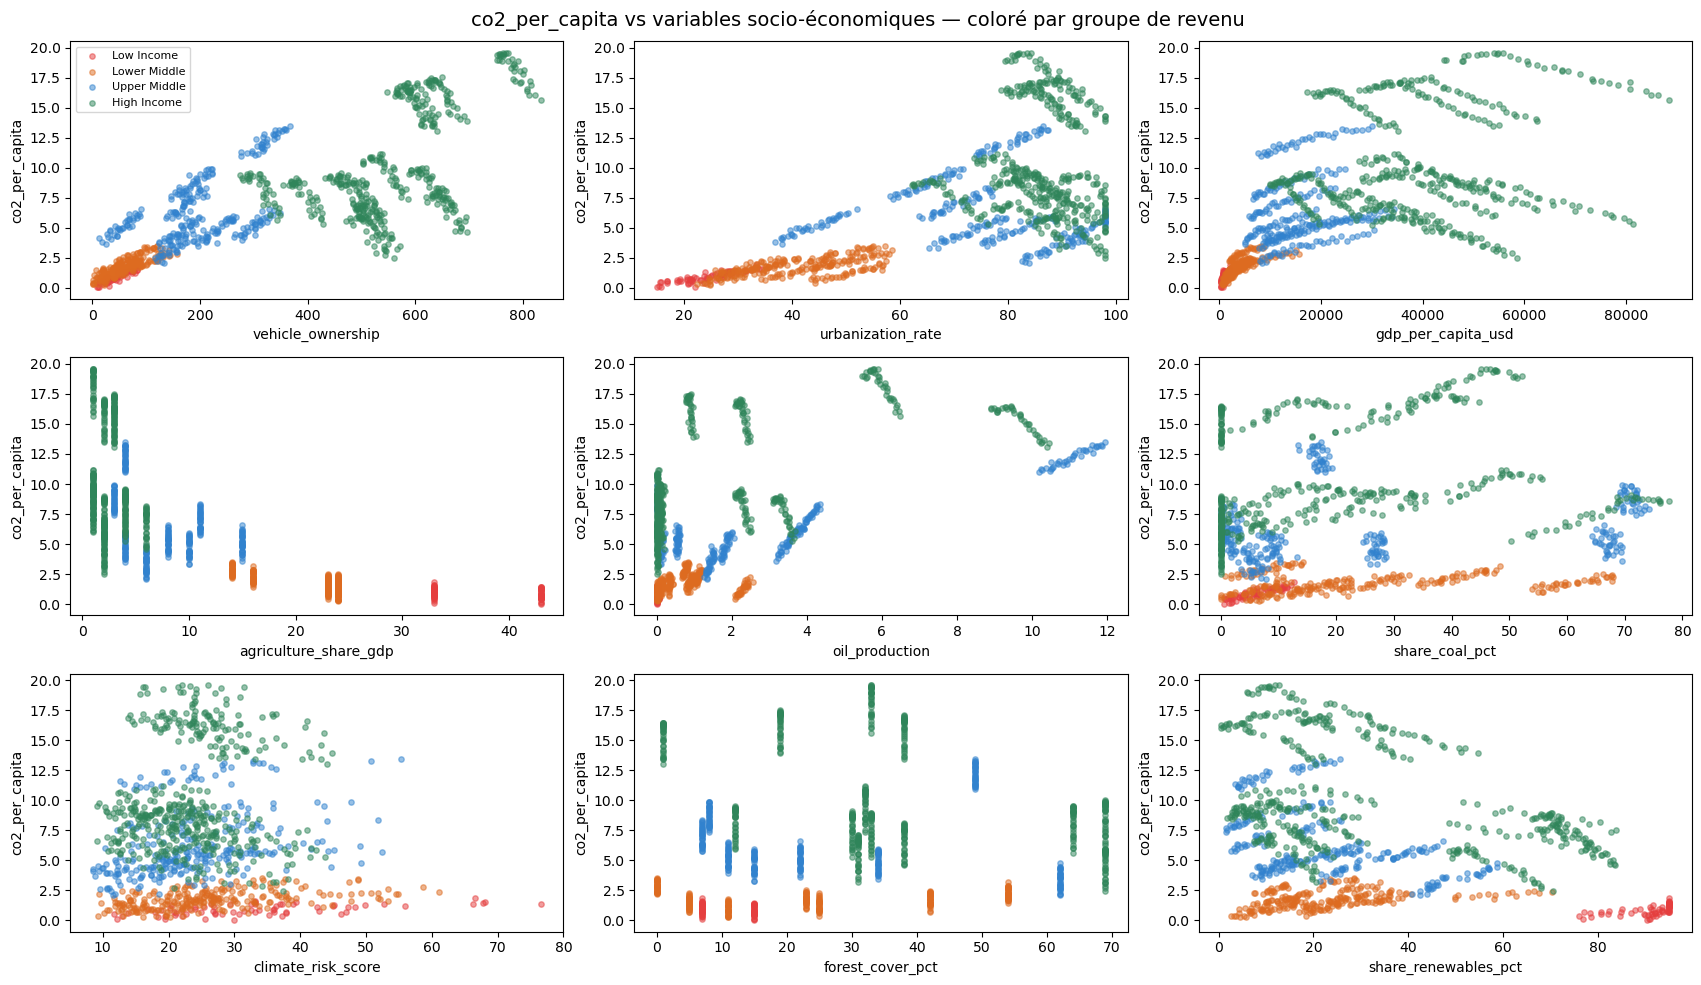

In [177]:
vars_to_plot = ['vehicle_ownership','urbanization_rate','gdp_per_capita_usd',
                'agriculture_share_gdp','oil_production','share_coal_pct','climate_risk_score','forest_cover_pct','share_renewables_pct']

# --- Version 1 : coloré par income_group ---
income_order = ['Low Income','Lower Middle','Upper Middle','High Income']
colors = {'Low Income':'#e53e3e','Lower Middle':'#dd6b20','Upper Middle':'#3182ce','High Income':'#2f855a'}

fig, axes = plt.subplots(3, 3, figsize=(17,10))
axes = axes.flatten()

for ax, var in zip(axes, vars_to_plot):
    for grp in income_order:
        sub = df_annual[df_annual['income_group']==grp]
        ax.scatter(sub[var], sub['co2_per_capita'], alpha=0.5, s=15, color=colors[grp], label=grp)
    ax.set_xlabel(var)
    ax.set_ylabel('co2_per_capita')

axes[0].legend(loc='upper left', fontsize=8)
plt.suptitle("co2_per_capita vs variables socio-économiques — coloré par groupe de revenu", fontsize=14)
plt.tight_layout()

Text(0.5, 0, 'gdp_per_capita_usd')

Text(0, 0.5, 'co2_per_capita')

Text(0.5, 1.0, 'Trajectoire par pays: PIB/hab')

Text(0.5, 0, 'oil_production')

Text(0, 0.5, 'co2_per_capita')

Text(0.5, 1.0, 'Trajectoire par pays: production pétrole')

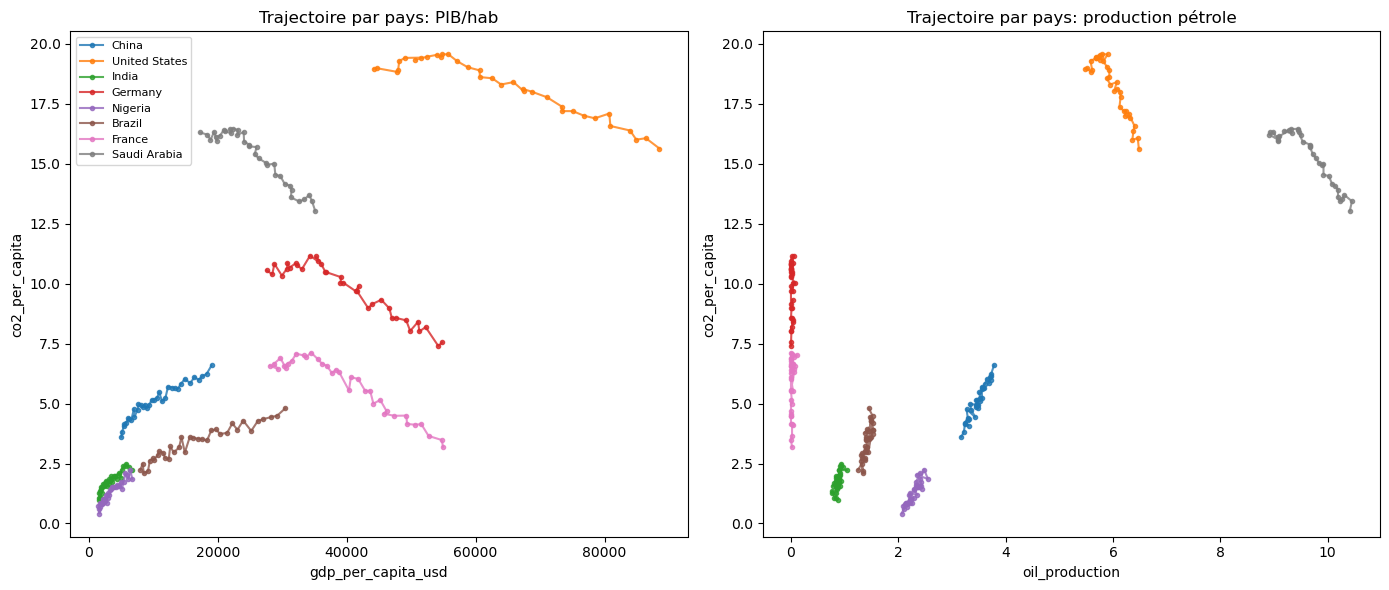

In [178]:
vars_to_plot = ['vehicle_ownership','urbanization_rate','gdp_per_capita_usd',
                'agriculture_share_gdp','oil_production','share_coal_pct']

# --- Version 2 : trajectoires par pays (quelques pays représentatifs) ---
sample_countries = ['China','United States','India','Germany','Nigeria','Brazil','France','Saudi Arabia']
fig, axes = plt.subplots(1, 2, figsize=(14,6))

for country in sample_countries:
    sub = df_annual[df_annual['country']==country].sort_values('year')
    axes[0].plot(sub['gdp_per_capita_usd'], sub['co2_per_capita'], marker='o', markersize=3, label=country, alpha=0.8)
    axes[1].plot(sub['oil_production'], sub['co2_per_capita'], marker='o', markersize=3, label=country, alpha=0.8)

axes[0].set_xlabel('gdp_per_capita_usd'); axes[0].set_ylabel('co2_per_capita'); axes[0].set_title('Trajectoire par pays: PIB/hab')
axes[1].set_xlabel('oil_production'); axes[1].set_ylabel('co2_per_capita'); axes[1].set_title('Trajectoire par pays: production pétrole')
axes[0].legend(fontsize=8)
plt.tight_layout()

ON COMMENCE LA MODELISATION

In [179]:
# ============================================================
# CELLULE 1 : PREPROCESSING
# ============================================================

import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder

# --- Chargement et passage à l'échelle annuelle ---
# Le CSV original a 12 lignes/an/pays (données mensuelles répétées),
# on ne garde qu'une ligne par pays/année pour avoir de vraies observations indépendantes
df = pd.read_csv("global_climate_co2_anomalies.csv")
df_annual = df.drop_duplicates(subset=['country','year'], keep='first')
df_annual = df_annual.sort_values(['country','year']).reset_index(drop=True)

# --- Définition de la cible et des features ---
target = 'co2_per_capita'

# Features numériques socio-économiques (variables de mode de vie / structure économique)
feature_cols = [
    'gdp_per_capita_usd','urbanization_rate','vehicle_ownership',
    'agriculture_share_gdp','industrial_share_gdp',
    'oil_production','share_coal_pct','share_renewables_pct',
    'forest_cover_pct','population_density'
]

# Features catégorielles
cat_cols = ['income_group','continent']

df_model = df_annual[['country','year',target] + feature_cols + cat_cols].copy()

# --- Gestion des valeurs manquantes ---

# vehicle_ownership a quelques NaN : on impute par la médiane du pays lui-même
# (plus logique que la médiane globale, qui mélangerait des pays très différents)
df_model['vehicle_ownership'] = df_model.groupby('country')['vehicle_ownership']\
    .transform(lambda x: x.fillna(x.median()))
df_model['vehicle_ownership'] = df_model['vehicle_ownership'].fillna(df_model['vehicle_ownership'].median())

# --- Création des features de lag (historique) ---
# Pour chaque variable clé, on ajoute sa valeur il y a 1, 2 et 5 ans
# groupby('country') est essentiel : on ne veut jamais mélanger l'historique
# d'un pays avec celui d'un autre pays
lag_source_cols = ['gdp_per_capita_usd','urbanization_rate','vehicle_ownership',
                    'oil_production','share_coal_pct','share_renewables_pct']

for lag in [1, 2, 5]:
    for col in lag_source_cols:
        df_model[f'{col}_lag{lag}'] = df_model.groupby('country')[col].shift(lag)

# --- Moyenne mobile 5 ans (tendance récente lissée) ---
# .shift(1) pour ne pas inclure l'année actuelle dans sa propre moyenne (fuite de données)
for col in lag_source_cols:
    df_model[f'{col}_ma5'] = df_model.groupby('country')[col]\
        .transform(lambda x: x.rolling(5, min_periods=1).mean().shift(1))

# Les premières années de chaque pays n'ont pas assez d'historique pour le lag5 -> NaN -> on les retire
df_model = df_model.dropna().reset_index(drop=True)

# --- Split train/test temporel ---
# Train = passé (1995-2016), Test = futur jamais vu (2017-2024)
# Volontairement PAS aléatoire : on veut tester la capacité à prédire le futur, pas mémoriser
train = df_model[df_model['year'] <= 2016].copy()
test  = df_model[df_model['year'] > 2016].copy()


# --- Encodage des variables catégorielles (one-hot) ---
# Le OneHotEncoder est "fit" uniquement sur le train, pour ne jamais laisser
# d'information du test influencer le preprocessing (fuite de données)
num_cols = [c for c in df_model.columns if c not in ['country','year',target]+cat_cols]

enc = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
enc.fit(train[cat_cols])

train_cat = pd.DataFrame(enc.transform(train[cat_cols]),
                          columns=enc.get_feature_names_out(cat_cols), index=train.index)
test_cat = pd.DataFrame(enc.transform(test[cat_cols]),
                         columns=enc.get_feature_names_out(cat_cols), index=test.index)

X_train = pd.concat([train[num_cols], train_cat], axis=1)
X_test  = pd.concat([test[num_cols], test_cat], axis=1)
y_train = train[target]
y_test  = test[target]

print(f"Train: {X_train.shape[0]} lignes, {X_train.shape[1]} features")
print(f"Test:  {X_test.shape[0]} lignes")

df_model.head()

OneHotEncoder(handle_unknown='ignore', sparse_output=False)

Train: 660 lignes, 44 features
Test:  240 lignes


,country,year,co2_per_capita,gdp_per_capita_usd,urbanization_rate,vehicle_ownership,agriculture_share_gdp,industrial_share_gdp,oil_production,share_coal_pct,share_renewables_pct,forest_cover_pct,population_density,income_group,continent,gdp_per_capita_usd_lag1,urbanization_rate_lag1,vehicle_ownership_lag1,oil_production_lag1,share_coal_pct_lag1,share_renewables_pct_lag1,gdp_per_capita_usd_lag2,urbanization_rate_lag2,vehicle_ownership_lag2,oil_production_lag2,share_coal_pct_lag2,share_renewables_pct_lag2,gdp_per_capita_usd_lag5,urbanization_rate_lag5,vehicle_ownership_lag5,oil_production_lag5,share_coal_pct_lag5,share_renewables_pct_lag5,gdp_per_capita_usd_ma5,urbanization_rate_ma5,vehicle_ownership_ma5,oil_production_ma5,share_coal_pct_ma5,share_renewables_pct_ma5
0,Argentina,1995,4.23,11130.0,90.9,282.0,8,23,0.55,1.5,10.9,11,13989.2,Upper Middle,South America,10295.0,92.2,275.0,0.51,2.6,9.6,10023.0,90.4,284.0,0.52,1.7,8.6,8749.0,89.0,264.0,0.51,2.3,9.4,9605.6,90.68,275.4,0.526,2.16,9.06
1,Argentina,1996,4.50,11545.0,92.5,282.0,8,23,0.48,1.2,11.1,11,14129.5,Upper Middle,South America,11130.0,90.9,282.0,0.55,1.5,10.9,10295.0,92.2,275.0,0.51,2.6,9.6,9421.0,89.9,276.0,0.56,2.5,8.0,10081.8,91.06,279.0,0.534,2.00,9.36
2,Argentina,1997,4.44,11890.0,93.1,265.0,8,23,0.55,1.9,8.6,11,14269.8,Upper Middle,South America,11545.0,92.5,282.0,0.48,1.2,11.1,11130.0,90.9,282.0,0.55,1.5,10.9,9540.0,91.9,278.0,0.53,1.7,9.7,10506.6,91.58,280.2,0.518,1.74,9.98
3,Argentina,1998,4.43,12338.0,93.3,302.0,8,23,0.50,0.1,11.2,11,14413.7,Upper Middle,South America,11890.0,93.1,265.0,0.55,1.9,8.6,11545.0,92.5,282.0,0.48,1.2,11.1,10023.0,90.4,284.0,0.52,1.7,8.6,10976.6,91.82,277.6,0.522,1.78,9.76
4,Argentina,1999,5.02,13053.0,92.4,287.0,8,23,0.52,0.4,11.5,11,14557.6,Upper Middle,South America,12338.0,93.3,302.0,0.50,0.1,11.2,11890.0,93.1,265.0,0.55,1.9,8.6,10295.0,92.2,275.0,0.51,2.6,9.6,11439.6,92.40,281.2,0.518,1.46,10.28


In [180]:
pip install optuna

Note: you may need to restart the kernel to use updated packages.


LinearRegression()

RandomForestRegressor(max_depth=8, n_estimators=300, n_jobs=-1, random_state=42)

=== Régression Linéaire ===
MAE:  1.628
RMSE: 2.039
R²:   0.767

=== Random Forest ===
MAE:  0.668
RMSE: 0.913
R²:   0.953



<Figure size 800x600 with 0 Axes>

<BarContainer object of 15 artists>

Text(0.5, 0, 'Importance')

Text(0.5, 1.0, 'Top 15 features les plus importantes (Random Forest)')

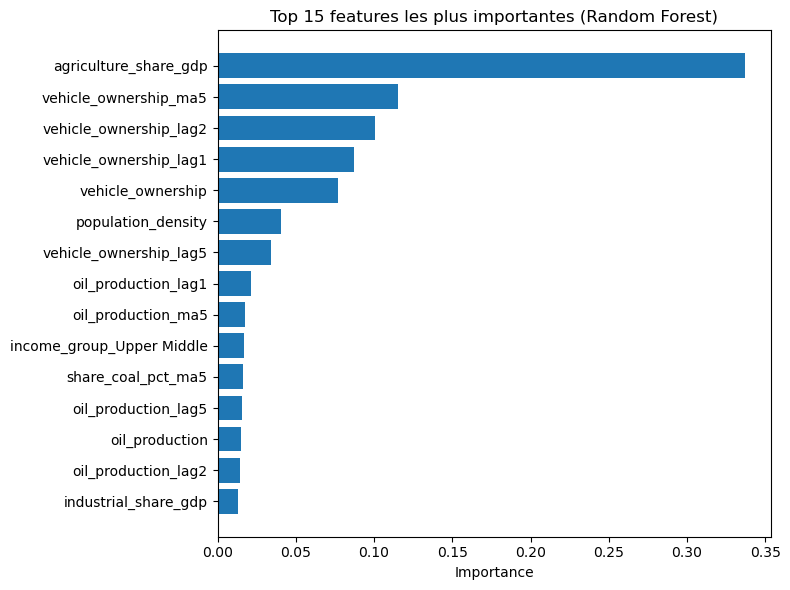

['model_results.pkl']

In [181]:
# ============================================================
# CELLULE 2 : ENTRAÎNEMENT DES MODÈLES
# ============================================================

import numpy as np
import pandas as pd
import sklearn
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import optuna

from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = 'all'

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

# --- Modèle 1 : Régression linéaire (baseline simple/interprétable) ---
lr = LinearRegression()
lr.fit(X_train, y_train)
pred_lr = lr.predict(X_test)

# --- Modèle 2 : Random Forest (capture non-linéarités et interactions) ---
rf = RandomForestRegressor(
    n_estimators=300,   # nombre d'arbres
    max_depth=8,        # profondeur max, limite le surapprentissage
    random_state=42,    # reproductibilité
    n_jobs=-1            # utilise tous les coeurs CPU disponibles
)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

# --- Évaluation ---
def evaluate(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"=== {name} ===")
    print(f"MAE:  {mae:.3f}")
    print(f"RMSE: {rmse:.3f}")

    print(f"R²:   {r2:.3f}\n")

evaluate(y_test, pred_lr, "Régression Linéaire")
evaluate(y_test, pred_rf, "Random Forest")

# --- Feature importance (Random Forest uniquement) ---
importances = pd.Series(rf.feature_importances_, index=X_train.columns)\
    .sort_values(ascending=False).head(15)

plt.figure(figsize=(8,6))
plt.barh(importances.index[::-1], importances.values[::-1])
plt.xlabel('Importance')
plt.title('Top 15 features les plus importantes (Random Forest)')
plt.tight_layout()
plt.show()

import joblib
joblib.dump({'rf':rf,'lr':lr,'X_train':X_train,'X_test':X_test,'y_train':y_train,'y_test':y_test,
             'pred_rf':pred_rf,'pred_lr':pred_lr,'test_meta':test[['country','year']]}, 'model_results.pkl')

In [182]:
def modelresults(predictions):
    mae = mean_absolute_error(y_test, predictions)
    mse = mean_squared_error(y_test, predictions)
    r2 = r2_score(y_test, predictions)
    
    print('Mean absolute error on model is {:.4f}'.format(mae))
    print('')
    print('Mean squared error on model is {:.4f}'.format(mse))
    print('')
    print('The r2 score on model is {:.4f}'.format(r2))

rfr = RandomForestRegressor(random_state = 21)
rfr.fit(X_train, y_train)
y_pred_rfr_fit = rfr.predict(X_test)


y_pred_rfr_fit = rfr.predict(X_test)

RandomForestRegressor(random_state=21)

Text(0.5, 0, 'Valeur réelle (co2_per_capita)')

Text(0, 0.5, 'Valeur prédite')

Text(0.5, 1.0, 'Random Forest — Prédictions vs Réalité (2017-2024)')

<BarContainer object of 15 artists>

Text(0.5, 0, 'Importance')

Text(0.5, 1.0, 'Top 15 features les plus importantes')

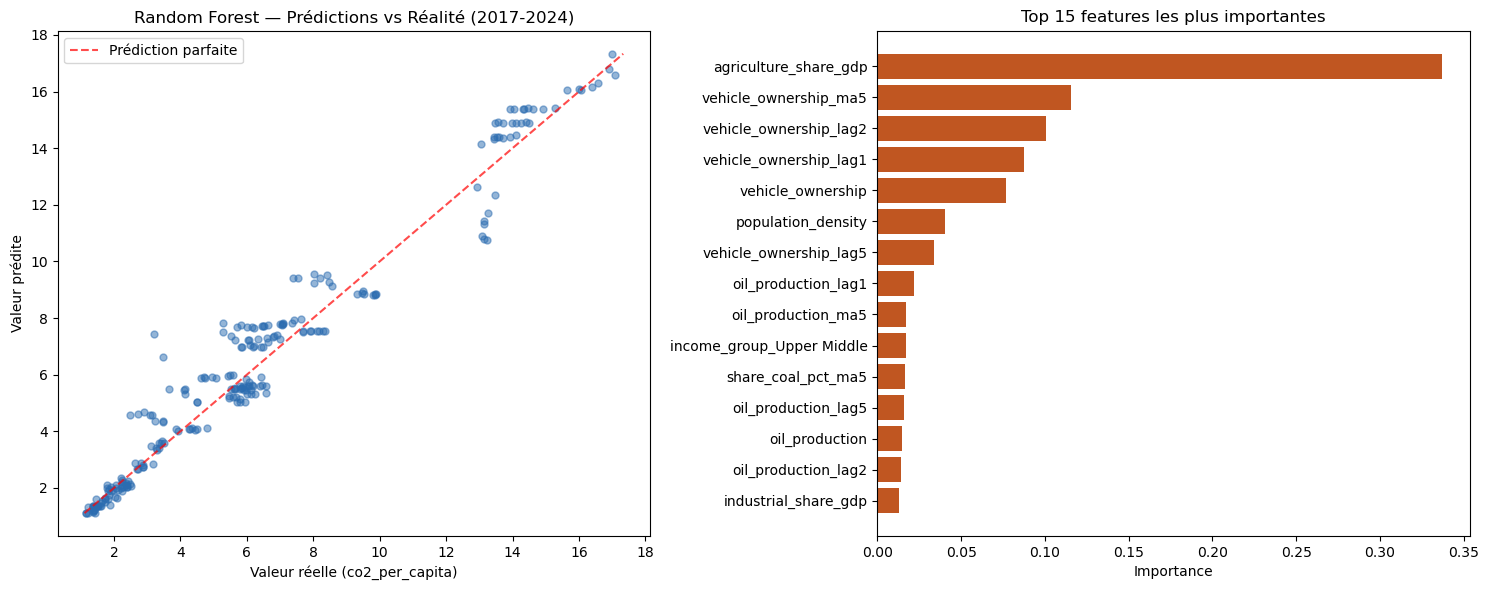

agriculture_share_gdp        0.336839
vehicle_ownership_ma5        0.115272
vehicle_ownership_lag2       0.100655
vehicle_ownership_lag1       0.087235
vehicle_ownership            0.076915
population_density           0.040252
vehicle_ownership_lag5       0.034063
oil_production_lag1          0.021586
oil_production_ma5           0.017253
income_group_Upper Middle    0.016890
share_coal_pct_ma5           0.016244
oil_production_lag5          0.015875
oil_production               0.014779
oil_production_lag2          0.014045
industrial_share_gdp         0.013207
dtype: float64


In [183]:
d = joblib.load('model_results.pkl')
rf, X_train, y_test, pred_rf = d['rf'], d['X_train'], d['y_test'], d['pred_rf']

fig, axes = plt.subplots(1, 2, figsize=(15,6))

# Prédictions vs réalité
axes[0].scatter(y_test, pred_rf, alpha=0.5, s=25, color='#2b6cb0')
lims = [min(y_test.min(),pred_rf.min()), max(y_test.max(),pred_rf.max())]
axes[0].plot(lims, lims, 'r--', alpha=0.7, label='Prédiction parfaite')
axes[0].set_xlabel('Valeur réelle (co2_per_capita)')
axes[0].set_ylabel('Valeur prédite')
axes[0].set_title('Random Forest — Prédictions vs Réalité (2017-2024)')
axes[0].legend()

# Feature importance (top 15)
importances = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(15)
axes[1].barh(importances.index[::-1], importances.values[::-1], color='#c05621')
axes[1].set_xlabel('Importance')
axes[1].set_title('Top 15 features les plus importantes')

plt.tight_layout()
plt.show()
print(importances)

OPTIMISATION RANDOM FOREST

In [184]:
# Define objective function
def objective(trial):
    # Suggest values for hyperparameters
    n_estimators = trial.suggest_int("n_estimators", 10, 200, log=True)
    max_depth = trial.suggest_int("max_depth", 2, 32)
    min_samples_split = trial.suggest_int("min_samples_split", 2, 10)
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 10)
    max_features = trial.suggest_categorical('max_features', ['sqrt', 'log2'])
    criterion = trial.suggest_categorical('criterion', ["squared_error", "absolute_error", "friedman_mse", "poisson"])

    # Create and fit random forest model
    model = RandomForestRegressor(
    n_estimators=n_estimators,
    max_depth=max_depth,
    min_samples_split=min_samples_split,
    min_samples_leaf=min_samples_leaf,
    random_state=42,
    max_features=max_features,
    criterion=criterion,
    )
    model.fit(X_train, y_train)

    # Make predictions and calculate RMSE
    y_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    # Return MAE
    return mae



In [185]:
# Create study object
study = optuna.create_study(direction="minimize")

# Run optimization process
study.optimize(objective, n_trials=200, show_progress_bar=True)

  0%|          | 0/200 [00:00<?, ?it/s]

In [186]:
# Print best trial and best hyperparameters
print("Best trial:", study.best_trial)
print("Best hyperparameters:", study.best_params)

Best trial: FrozenTrial(number=70, state=<TrialState.COMPLETE: 1>, values=[0.5071465863453821], datetime_start=datetime.datetime(2026, 9, 19, 12, 33, 50, 918271), datetime_complete=datetime.datetime(2026, 9, 19, 12, 33, 51, 631778), params={'n_estimators': 83, 'max_depth': 19, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'criterion': 'absolute_error'}, user_attrs={}, system_attrs={'tpe:relative_params:0': '{"criterion": "absolute_error", "max_depth": 19, "max_features": "log2", "min_samples_leaf": 1, "min_samples_split": 2, "n_estimators": 83}'}, intermediate_values={}, distributions={'n_estimators': IntDistribution(high=200, log=True, low=10, step=1), 'max_depth': IntDistribution(high=32, log=False, low=2, step=1), 'min_samples_split': IntDistribution(high=10, log=False, low=2, step=1), 'min_samples_leaf': IntDistribution(high=10, log=False, low=1, step=1), 'max_features': CategoricalDistribution(choices=('sqrt', 'log2')), 'criterion': CategoricalDistribution

In [187]:
# Import optuna.visualization
import optuna.visualization as vis

# Plot optimization history
vis.plot_optimization_history(study)

# Plot parameter importance
vis.plot_param_importances(study)

# Plot slice plot
vis.plot_slice(study, params=["n_estimators", "max_depth"])

# Plot contour plot
vis.plot_contour(study, params=["min_samples_split", "min_samples_leaf"])

# Plot parallel_coordinate
vis.plot_parallel_coordinate(study)

In [188]:
best_params = study.best_params

best_n_estimators = best_params['n_estimators']
best_max_depth = best_params['max_depth']
best_min_samples_split = best_params['min_samples_split']
best_min_samples_leaf = best_params['min_samples_leaf']
best_max_features = best_params['max_features']
best_criterion = best_params['criterion']


In [189]:
best_model = RandomForestRegressor( n_estimators = best_n_estimators,
                                  max_depth = best_max_depth,
                                  min_samples_split = best_min_samples_split,
                                  min_samples_leaf =  best_min_samples_leaf,
                                  )

best_model.fit(X_train, y_train)

y_pred_rfr_optuna_200_trails = best_model.predict(X_test)

modelresults(y_pred_rfr_optuna_200_trails)

RandomForestRegressor(max_depth=19, n_estimators=83)

Mean absolute error on model is 0.6479

Mean squared error on model is 0.8244

The r2 score on model is 0.9537


In [190]:
def modelresults(predictions, model_name):
    mae = mean_absolute_error(y_test, predictions)
    mse = mean_squared_error(y_test, predictions)
    r2 = r2_score(y_test, predictions)

    results_dict = {
        'Model': model_name,
        'MAE': mae,
        'MSE': mse,
        'R2 Score': r2
    }
    
    print('Results for {}:'.format(model_name))
    print('Mean absolute error on model is {:.4f}'.format(mae))
    print('Mean squared error on model is {:.4f}'.format(mse))
    print('The r2 score on model is {:.4f}'.format(r2))
    
    return results_dict


results_fit = modelresults(y_pred_rfr_fit, 'Random Forest Fit')
results_optuna_200 = modelresults(y_pred_rfr_optuna_200_trails, 'Random Forest Optuna (200 trials)')

results_df = pd.DataFrame([results_fit, results_optuna_200])
print(results_df)

Results for Random Forest Fit:
Mean absolute error on model is 0.6430
Mean squared error on model is 0.7703
The r2 score on model is 0.9568
Results for Random Forest Optuna (200 trials):
Mean absolute error on model is 0.6479
Mean squared error on model is 0.8244
The r2 score on model is 0.9537
                               Model       MAE       MSE  R2 Score
0                  Random Forest Fit  0.642975  0.770300  0.956784
1  Random Forest Optuna (200 trials)  0.647907  0.824432  0.953747


In [191]:
##ON ESSAYE MTN AVEC 1000 TRIALS AU LIEU DE 200 POUR VOIR SI ON PEUT AMELIORER LE MODELE

In [192]:
def objective(trial):
    n_estimators = trial.suggest_int('n_estimators', 100, 1000)
    max_depth = trial.suggest_int('max_depth', 10, 50)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 32)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 32)
    max_features = trial.suggest_categorical('max_features', ['sqrt', 'log2'])
    criterion = trial.suggest_categorical('criterion', ["squared_error", "absolute_error", "friedman_mse", "poisson"])

    model = RandomForestRegressor(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        criterion=criterion,
        random_state=21  )

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # metric to optimize
    score = mean_squared_error(y_test, y_pred)
    
    return score

study = optuna.create_study(direction='minimize', sampler=optuna.samplers.RandomSampler(seed=42))
study.optimize(objective, n_trials=1000)

# Print the best parameters found 
print("Best trial:")
trial = study.best_trial

print("Value: {:.4f}".format(trial.value))

print("Params: ")
for key, value in trial.params.items():
    print("    {}: {}".format(key, value))

Best trial:
Value: 0.5788
Params: 
    n_estimators: 353
    max_depth: 17
    min_samples_split: 3
    min_samples_leaf: 1
    max_features: sqrt
    criterion: absolute_error


In [194]:
# Récupérer les VRAIS meilleurs hyperparamètres de l'étude à 1000 trials
best_params_1000 = study.best_params  # 'study' = celui de la cellule 37 (1000 trials)

best_model_1000 = RandomForestRegressor(
    n_estimators=best_params_1000['n_estimators'],
    max_depth=best_params_1000['max_depth'],
    min_samples_split=best_params_1000['min_samples_split'],
    min_samples_leaf=best_params_1000['min_samples_leaf'],
    max_features=best_params_1000['max_features'],   # <- manquait
    criterion=best_params_1000['criterion'],           # <- manquait
    random_state=42                                      # <- pour la reproductibilité
)
best_model_1000.fit(X_train, y_train)

y_pred_rfr_optuna_1000_trials = best_model_1000.predict(X_test)

results_optuna_1000 = modelresults(y_pred_rfr_optuna_1000_trials, 'Random Forest Optuna (1000 trials)')

RandomForestRegressor(criterion='absolute_error', max_depth=17,
                      max_features='sqrt', min_samples_split=3,
                      n_estimators=353, random_state=42)

Results for Random Forest Optuna (1000 trials):
Mean absolute error on model is 0.5572
Mean squared error on model is 0.5965
The r2 score on model is 0.9665


In [195]:
def modelresults(predictions, model_name):
    mae = mean_absolute_error(y_test, predictions)
    mse = mean_squared_error(y_test, predictions)
    r2 = r2_score(y_test, predictions)

    results_dict = {
        'Model': model_name,
        'MAE': mae,
        'MSE': mse,
        'R2 Score': r2
    }
    
    print('Results for {}:'.format(model_name))
    print('Mean absolute error on model is {:.4f}'.format(mae))
    print('Mean squared error on model is {:.4f}'.format(mse))
    print('The r2 score on model is {:.4f}'.format(r2))
    
    return results_dict


results_fit = modelresults(y_pred_rfr_fit, 'Random Forest Fit')
results_optuna_200 = modelresults(y_pred_rfr_optuna_200_trails, 'Random Forest Optuna (200 trials)')
results_optuna_1000 = modelresults(y_pred_rfr_optuna_1000_trails, 'Random Forest Optuna (1000 trials)')

results_df = pd.DataFrame([results_fit, results_optuna_200, results_optuna_1000])
print(results_df)

Results for Random Forest Fit:
Mean absolute error on model is 0.6430
Mean squared error on model is 0.7703
The r2 score on model is 0.9568
Results for Random Forest Optuna (200 trials):
Mean absolute error on model is 0.6479
Mean squared error on model is 0.8244
The r2 score on model is 0.9537
Results for Random Forest Optuna (1000 trials):
Mean absolute error on model is 0.6497
Mean squared error on model is 0.8243
The r2 score on model is 0.9538
                                Model       MAE       MSE  R2 Score
0                   Random Forest Fit  0.642975  0.770300  0.956784
1   Random Forest Optuna (200 trials)  0.647907  0.824432  0.953747
2  Random Forest Optuna (1000 trials)  0.649685  0.824293  0.953754


In [ ]:
## augmenter à 1000 trials n'a pas amélioré le modèle, donc on garde les hyperparamètres de 200 trials

In [ ]:
#J'aimerais faire la courbe d'apprentissage 

<Figure size 800x500 with 0 Axes>

Text(0.5, 0, "Nombre d'exemples d'entraînement")

Text(0, 0.5, 'MAE (plus bas = mieux)')

Text(0.5, 1.0, "Courbe d'apprentissage — Random Forest optimisé")

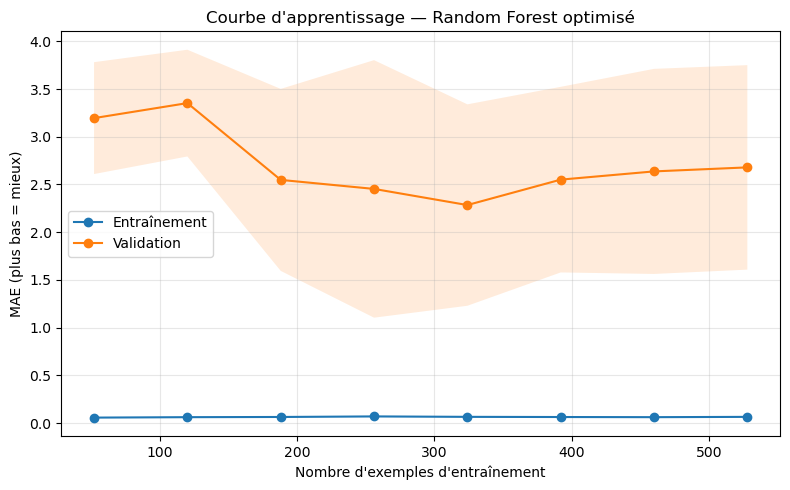

In [196]:
# --- Courbe d'apprentissage (corrigée) ---
from sklearn.model_selection import learning_curve, TimeSeriesSplit

# Option simple (cohérente avec ton code d'origine, juste le bug scoring corrigé)
train_sizes, train_scores, val_scores = learning_curve(
    best_model, X_train, y_train,          # <- best_model (optimisé), pas rf
    train_sizes=np.linspace(0.1, 1.0, 8),
    cv=5, scoring="neg_mean_absolute_error", n_jobs=-1, random_state=42
)

# neg_mean_absolute_error retourne des valeurs négatives (convention sklearn) -> on repasse en positif
train_mean, train_std = -train_scores.mean(axis=1), train_scores.std(axis=1)
val_mean, val_std = -val_scores.mean(axis=1), val_scores.std(axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_mean, "o-", label="Entraînement")
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15)
plt.plot(train_sizes, val_mean, "o-", label="Validation")
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15)
plt.xlabel("Nombre d'exemples d'entraînement")
plt.ylabel("MAE (plus bas = mieux)")
plt.title("Courbe d'apprentissage — Random Forest optimisé")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()